In [117]:
import pandas as pd
import numpy as np
import os.path as path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

## 1.Analsisi Karakteristik Dataset

In [118]:
df = pd.read_csv('../1.FIFA Transfer Market Analytics/fifa_player_performance_market_value.csv')
df.head()

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   object 
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   object 
 4   club                      2800 non-null   object 
 5   position                  2800 non-null   object 
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 non-null   int64  
 14  injury_p

In [120]:
df.shape

(2800, 16)

In [121]:
df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
dtype: int64

In [122]:
df.duplicated().sum()

np.int64(0)

In [123]:
df = df.drop(columns=['player_id','player_name'])
df.shape

(2800, 14)

In [124]:
for col in df.columns:
    print(f"Nilai unik untuk kolom '{col}':")
    print(df[col].unique())
    print("-" * 40)

Nilai unik untuk kolom 'age':
[23 36 31 27 24 37 35 39 20 19 38 18 28 22 17 33 26 32 21 25 34 30 29]
----------------------------------------
Nilai unik untuk kolom 'nationality':
['Germany' 'England' 'France' 'Portugal' 'Brazil' 'Argentina'
 'Netherlands' 'Spain']
----------------------------------------
Nilai unik untuk kolom 'club':
['Liverpool' 'FC Barcelona' 'Juventus' 'Manchester City' 'Bayern Munich'
 'PSG' 'Real Madrid']
----------------------------------------
Nilai unik untuk kolom 'position':
['ST' 'RB' 'LW' 'CDM' 'CM' 'GK' 'LB' 'RW' 'CB']
----------------------------------------
Nilai unik untuk kolom 'overall_rating':
[65 90 75 84 92 72 69 83 62 93 87 78 82 91 64 66 81 89 77 67 74 63 85 60
 79 80 71 68 73 61 70 88 76 86 94]
----------------------------------------
Nilai unik untuk kolom 'potential_rating':
[87 76 91 86 96 66 97 90 92 83 69 84 94 72 81 65 67 95 68 80 77 88 98 89
 82 79 70 78 71 73 74 85 93 75]
----------------------------------------
Nilai unik untuk kolom 

In [125]:
feature_numerik = ["age","overall_rating", "potential_rating", "matches_played", "goals", "assists", "minutes_played", "market_value_million_eur", "contract_years_left"]
feature_categori = ["nationality","club","position","injury_prone"]
feature_target = "transfer_risk_level"

## 2.Analisis Unvariat

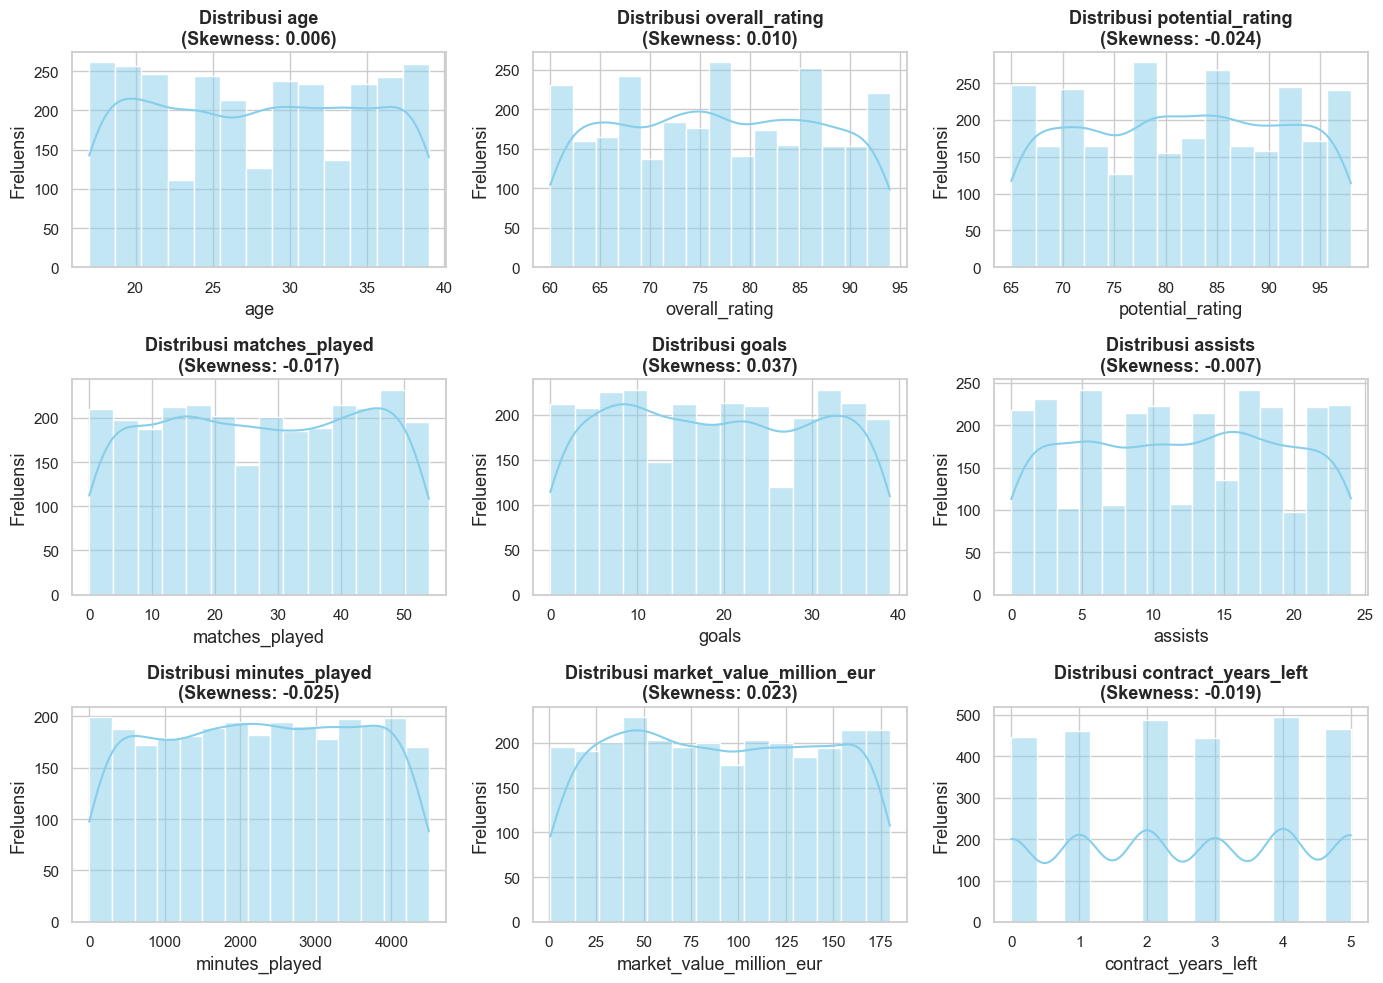

In [126]:
sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(3,3,figsize=(14,10))
axes = axes.flatten()

for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='skyblue',bins='auto')
    axes[i].set_title(f'Distribusi {feature}\n(Skewness: {feat_skew:.3f})',fontsize=13,fontweight='bold')
    axes[i].set_xlabel(feature,fontsize=13)
    axes[i].set_ylabel('Freluensi',fontsize=13)
plt.tight_layout()
plt.show()

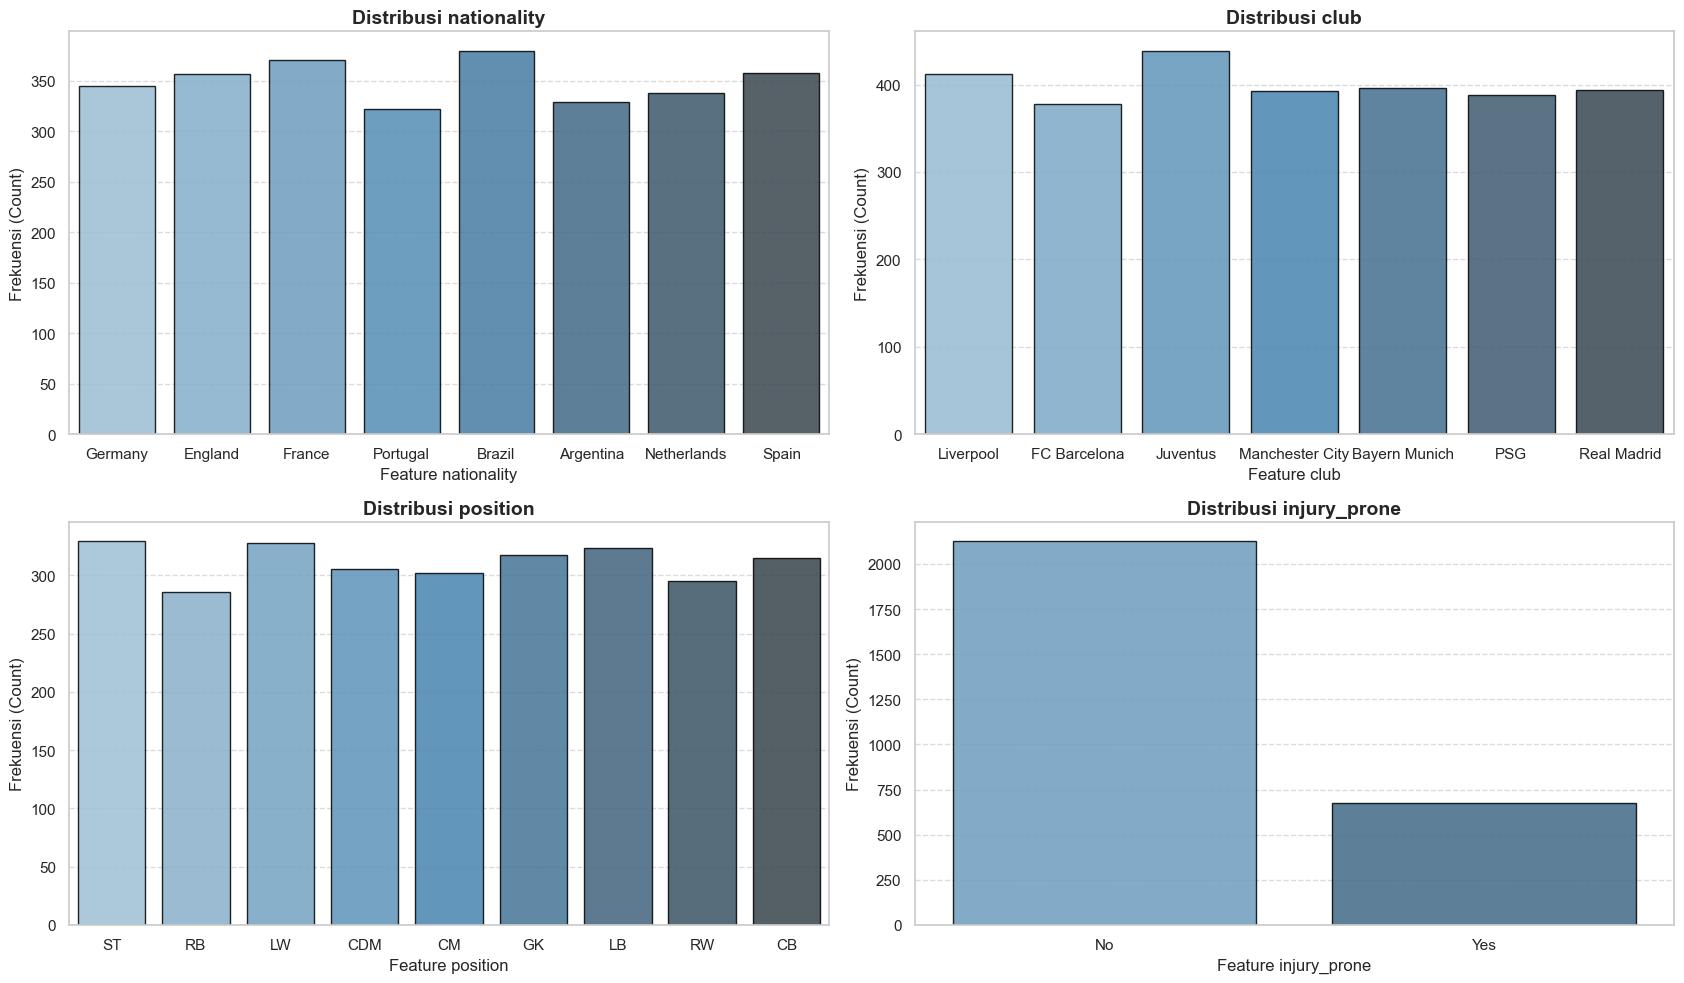

In [127]:
sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(2,2,figsize=(17,10))
axes = axes.flatten()

for i,feature in enumerate(feature_categori):
    sns.countplot(data=df,x=feature,hue=feature,ax=axes[i],palette='Blues_d',edgecolor='black',alpha=0.85)
    axes[i].set_title(f"Distribusi {feature}",fontsize=14,fontweight="bold",)
    axes[i].set_xlabel(f"Feature {feature}", fontsize=12)
    axes[i].set_ylabel("Frekuensi (Count)", fontsize=12)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## 3. Analisis Bivariat

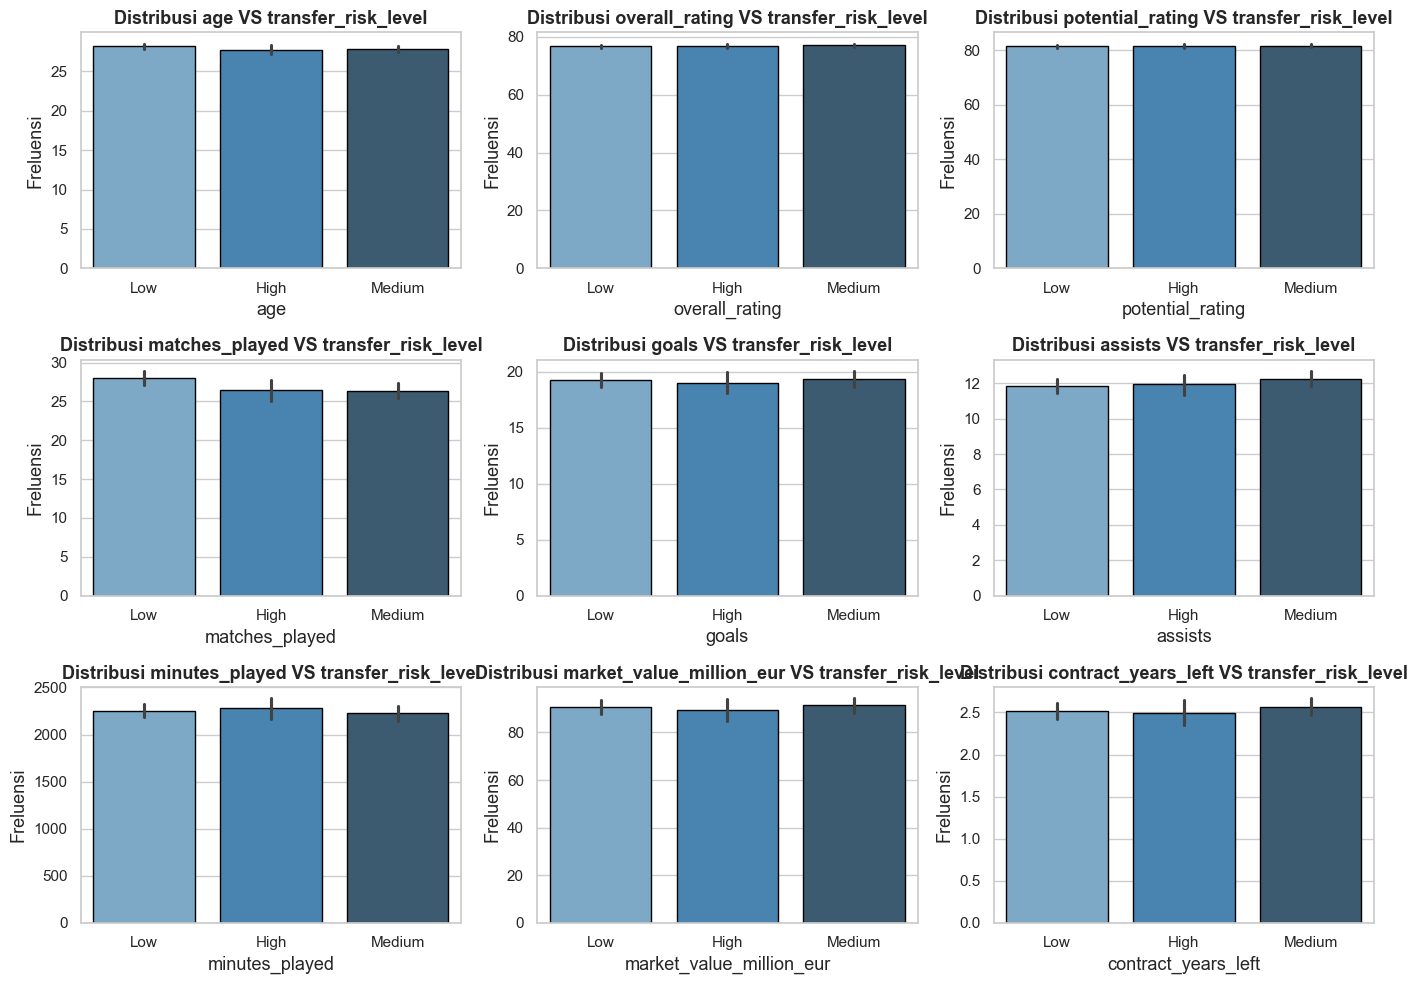

In [128]:
sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(3,3,figsize=(14,10))
axes = axes.flatten()

for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.barplot(data=df,ax=axes[i],x=feature_target, y=feature,hue=feature_target,palette='Blues_d',edgecolor='black')
    axes[i].set_title(f'Distribusi {feature} VS {feature_target}',fontsize=13,fontweight='bold')
    axes[i].set_xlabel(feature,fontsize=13)
    axes[i].set_ylabel('Freluensi',fontsize=13)
plt.tight_layout()
plt.show()

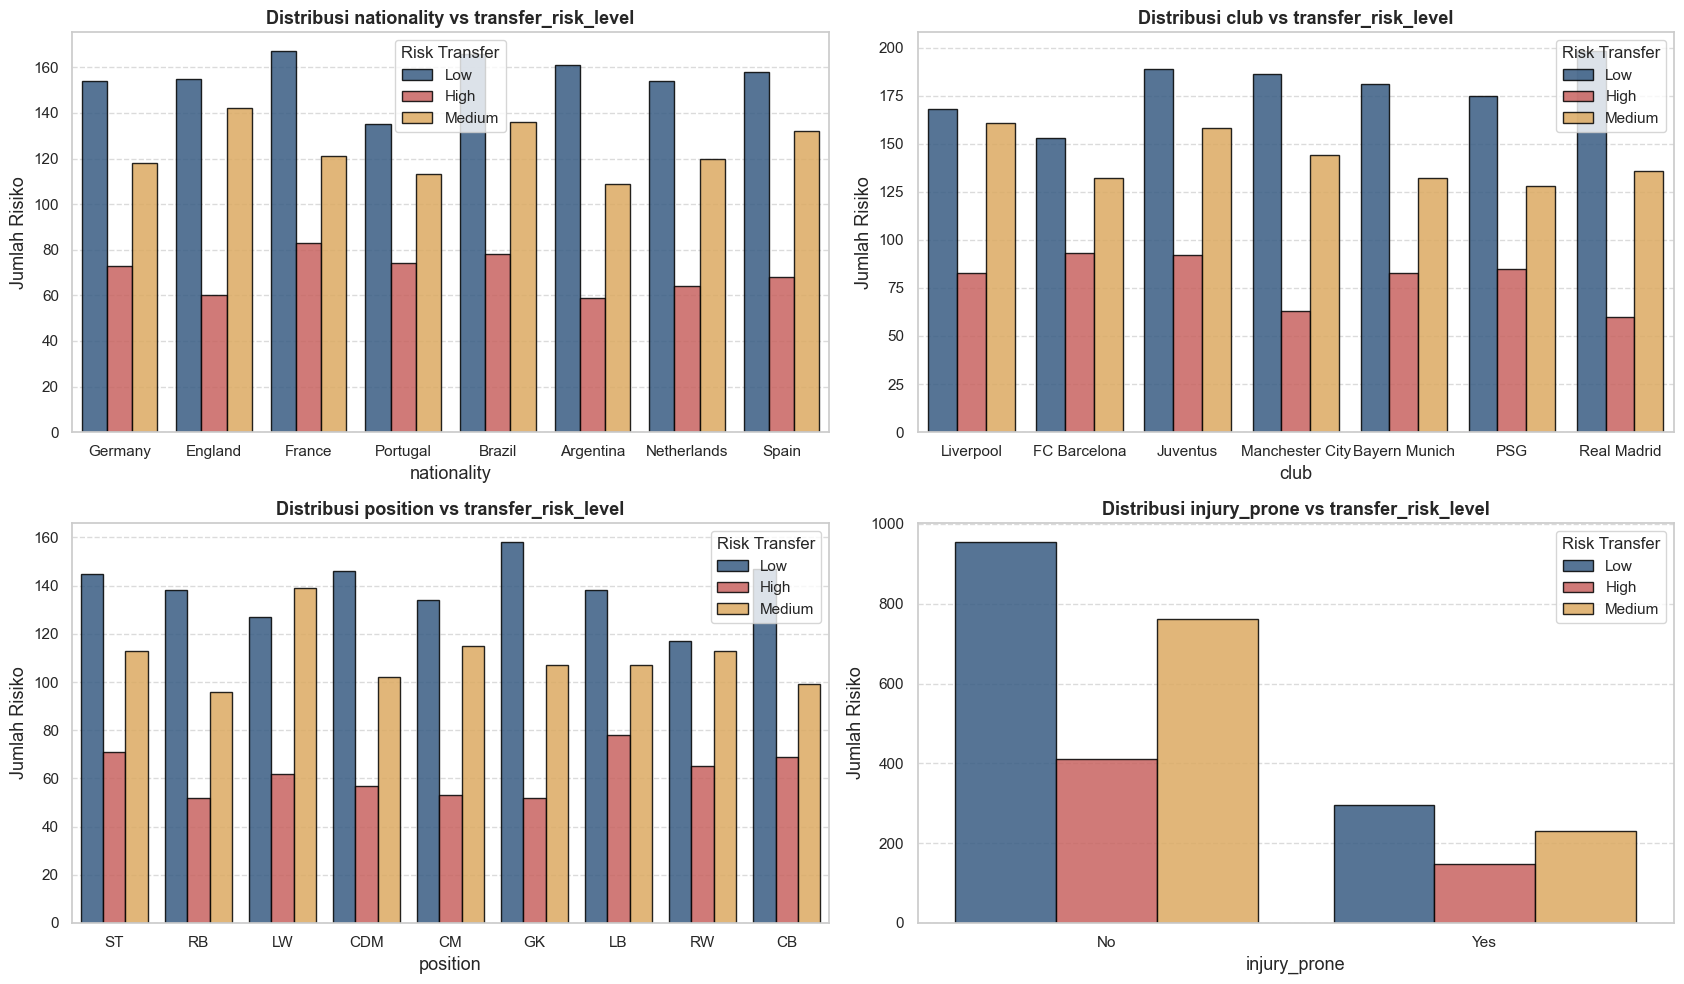

In [129]:
sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(2,2,figsize=(17,10))
axes = axes.flatten()

colors = {"Low": "#2b5c8f", "Medium": "#f0ad4e", "High": "#d9534f"}
for i,feature in enumerate(feature_categori):
    sns.countplot(data=df,x=feature,hue=feature_target,ax=axes[i],palette=colors,edgecolor='black',alpha=0.85)
    axes[i].set_title(f'Distribusi {feature} vs {feature_target}',fontsize=13,fontweight='bold')
    axes[i].set_xlabel(feature,fontsize=13)
    axes[i].set_ylabel('Jumlah Risiko',fontsize=13)
    axes[i].legend(title='Risk Transfer')
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 4.Analisis Multivariat

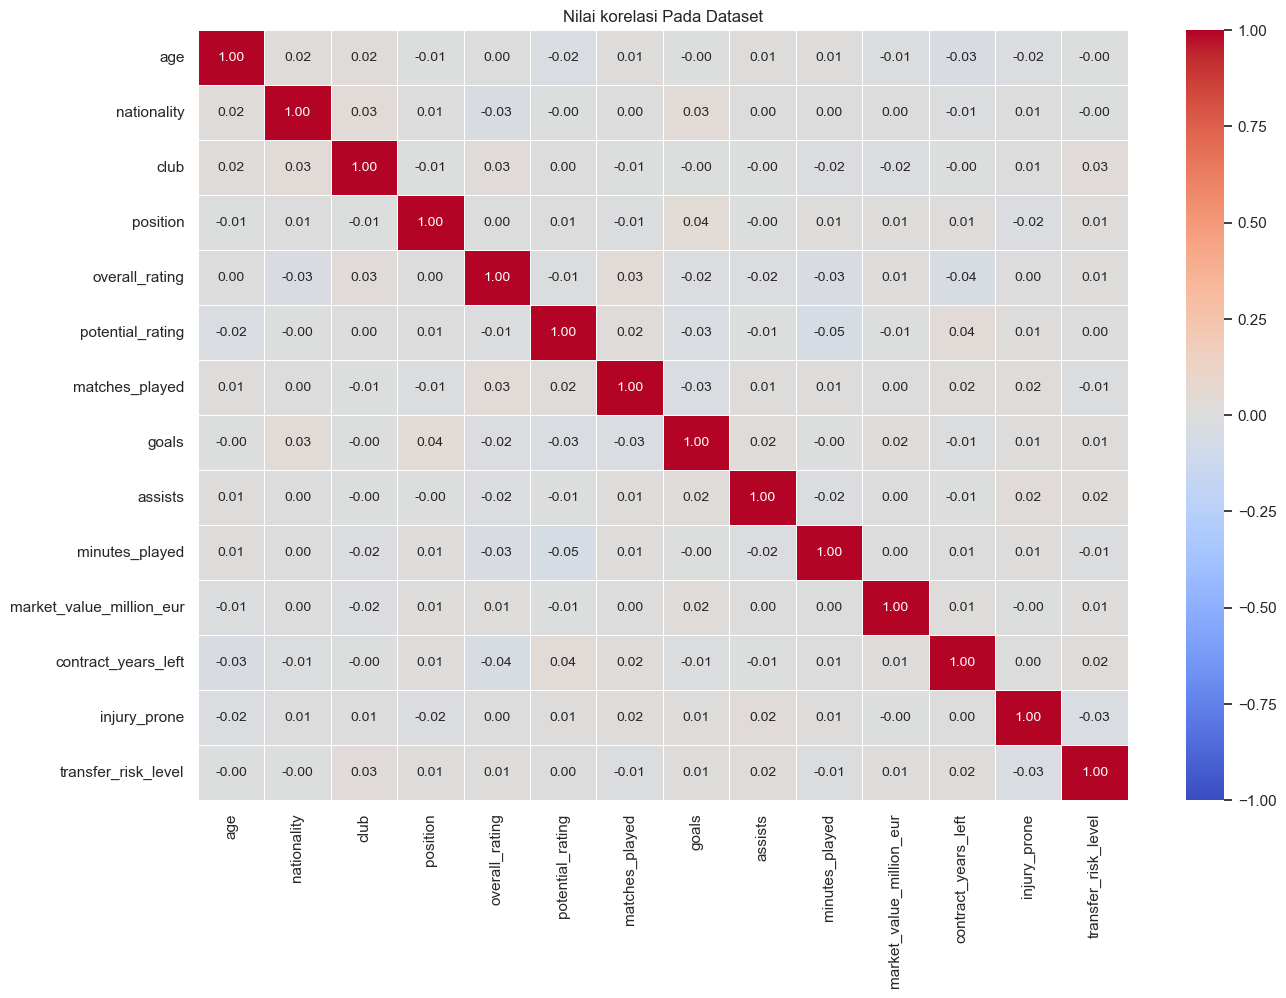

In [130]:
df_target = df.copy()
feature_categori = ["nationality","club","position","injury_prone","transfer_risk_level"]

label = LabelEncoder()
for col in feature_categori:
    df_target[col] = label.fit_transform(df_target[col])

plt.figure(figsize=(15,10))
corellation_matrix = df_target.corr()
sns.heatmap(corellation_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1,fmt='.2f',linewidths=0.5,annot_kws={"size": 10})
plt.title('Nilai korelasi Pada Dataset')
plt.show()

## 5.Analisis Outliers

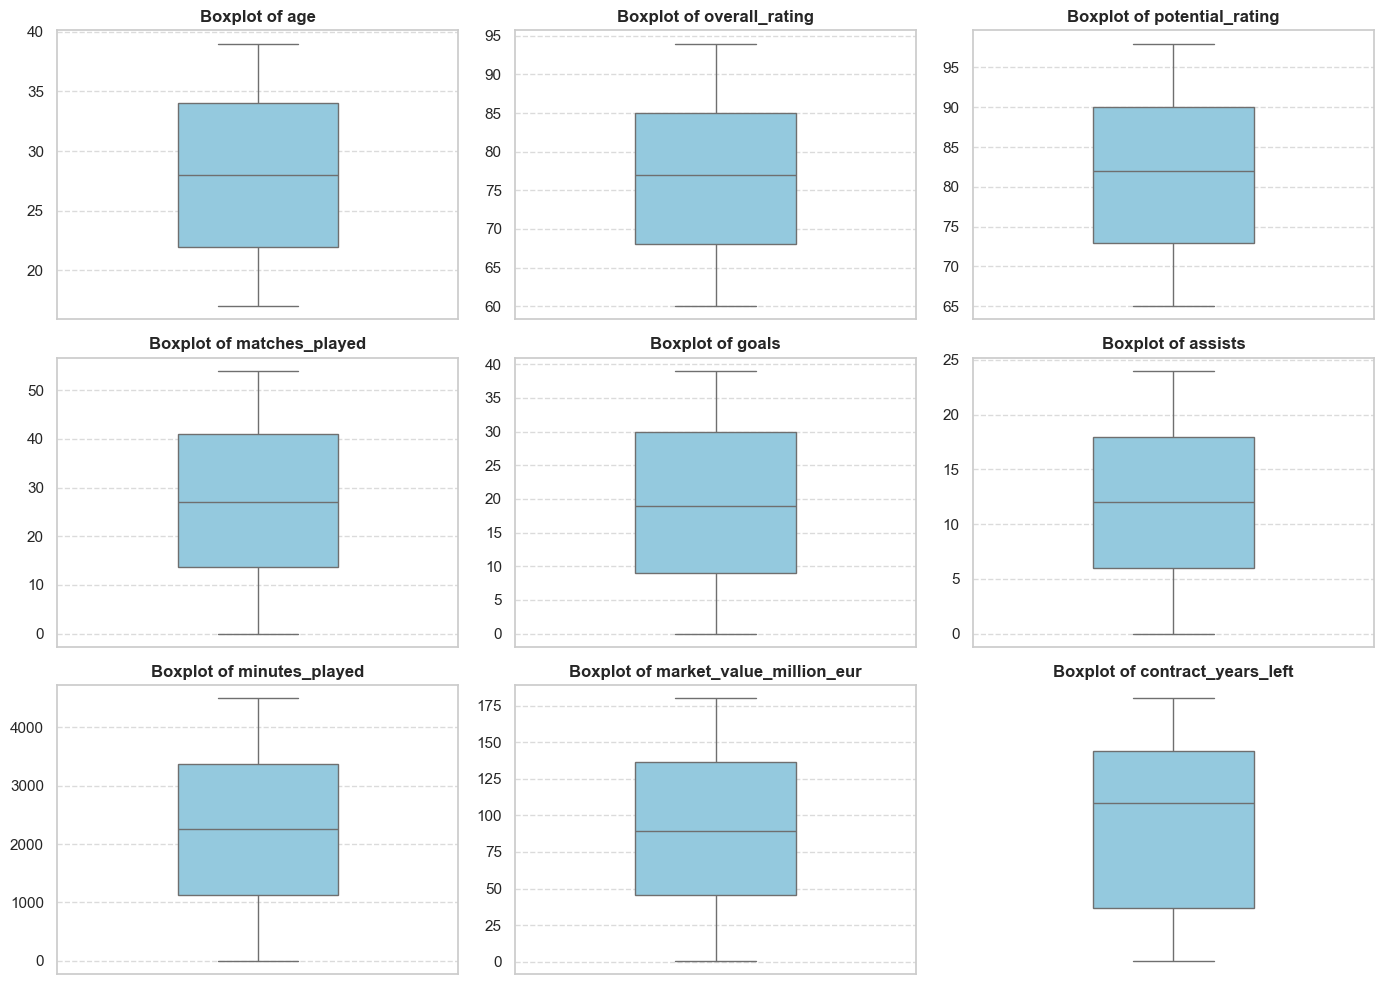

Jumlah outliers terdeteksi: 0


In [132]:
Q1 = df[feature_numerik].quantile(0.25)
Q3 = df[feature_numerik].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df.loc[((df[feature_numerik] < lower_bound) | (df[feature_numerik] > upper_bound)).any(axis=1)]

fig,axes = plt.subplots(3,3,figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Mengosongkan label y agar lebih bersih
    axes[i].grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan garis bantu
axes[-1].axis('off')
plt.tight_layout()
plt.show()
print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

## 6. Save Data

In [134]:
file_path = "../1.FIFA Transfer Market Analytics/fifa_player_performance_market_value_CLEANED.csv"

if not path.exists(file_path):
    # Jika BELUM ADA, simpan data ke CSV
    df.to_csv(file_path, index=False)
    print("File belum ada. Berhasil menyimpan dataset baru!")
else:
    # Jika SUDAH ADA, lewati proses penyimpanan
    print("File sudah ada. Proses penyimpanan CSV dilewati (skip).")

df.head()

File belum ada. Berhasil menyimpan dataset baru!


,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low
